In [9]:

!pip install ucimlrepo




In [6]:

# Import required libraries
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

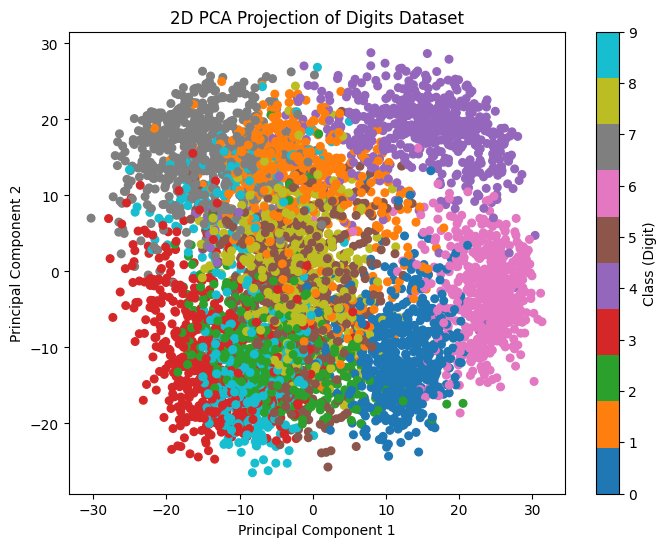

In [11]:
handwritten_digits = fetch_ucirepo(id=80)
X = handwritten_digits.data.features
y = handwritten_digits.data.targets
y = y.values.ravel().astype(int)


# Step 2: Apply PCA to reduce to 2D

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Plot 2D PCA projection
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=30)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Digits Dataset")
plt.colorbar(scatter, label="Class (Digit)")
plt.show()

In [12]:
#step 4: Supervisedlearningbaseling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

# Split into train and test set, stratifying to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y, stratify=y, test_size=0.3, random_state=42
)

svm = SVC(C=0.01, kernel='linear', probability=True)
svm.fit(X_train, y_train)
# Predict on test data
y_pred = svm.predict(X_test)

# Evaluate performance
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       166
           1       0.97      0.99      0.98       171
           2       0.99      0.99      0.99       167
           3       0.99      0.98      0.98       172
           4       0.99      0.98      0.99       171
           5       0.97      0.98      0.97       167
           6       1.00      0.99      1.00       167
           7       0.97      0.99      0.98       170
           8       0.96      0.95      0.95       166
           9       0.98      0.95      0.96       169

    accuracy                           0.98      1686
   macro avg       0.98      0.98      0.98      1686
weighted avg       0.98      0.98      0.98      1686



/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 

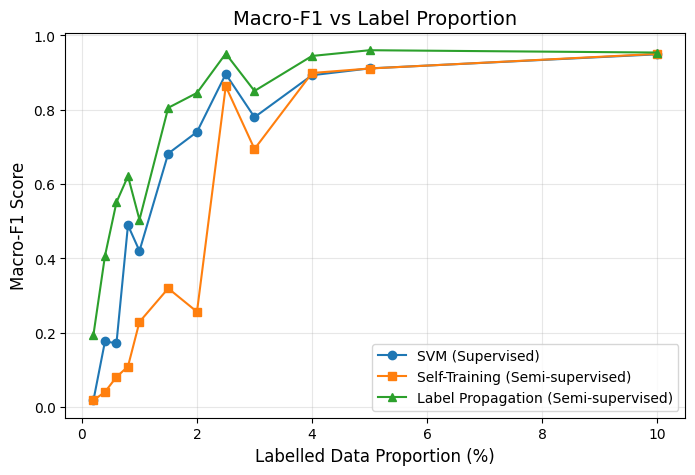

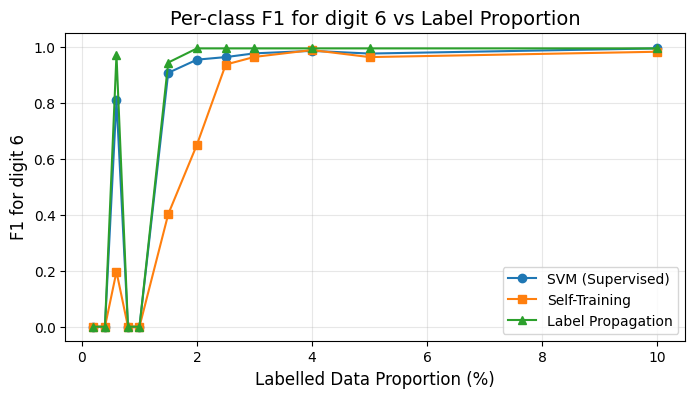

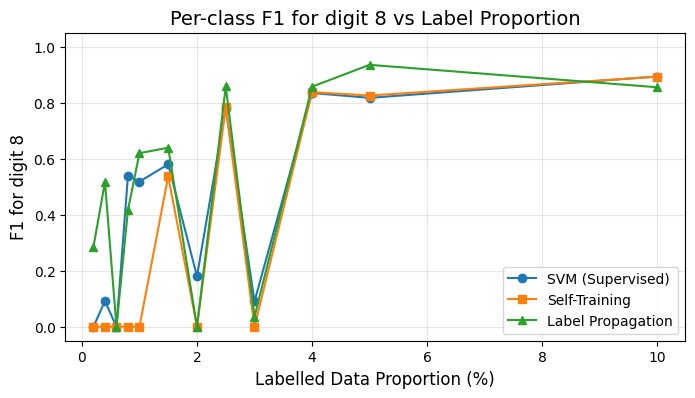

In [13]:
propagation = [0.002, 0.004, 0.006, 0.008, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05, 0.1]

results = {
    "svm": {"accuracy":[], "macro-F1": [], "macro-recall":[], "macro-precision":[], "f1_class6":[], "f1_class8":[]},
    "self": {"accuracy": [], "macro-F1":[], "macro-recall":[], "macro-precision":[], "f1_class6":[], "f1_class8":[]},
    "propg": {"accuracy": [], "macro-F1":[], "macro-recall":[], "macro-precision":[], "f1_class6":[], "f1_class8":[]}
}

# Convert to numpy arrays and flatten y
y_train = np.array(y_train).ravel()
X_train = np.array(X_train)
X_test = np.array(X_test)
y_test = np.array(y_test).ravel()

rng = np.random.RandomState(42)

for p in propagation:
    n_total = len(X_train)
    n_labeled = max(1, int(p * n_total))
    indices = np.arange(n_total)
    rng.shuffle(indices)
    labeled_idx = indices[:n_labeled]
    unlabeled_idx = indices[n_labeled:]

    # Create semi-supervised labels
    y_train_full = y_train.copy()
    y_train_full[unlabeled_idx] = -1

    # --- Supervised SVM ---
    svm = SVC(C=0.01, kernel='linear', random_state=42)
    svm.fit(X_train[labeled_idx], y_train[labeled_idx])
    y_pred_svm = svm.predict(X_test)

    # --- Self-Training ---
    base_svm = SVC(kernel="linear", C=0.01, probability=True, random_state=42)
    self_training = SelfTrainingClassifier(base_svm, criterion="k_best", max_iter=100)
    self_training.fit(X_train, y_train_full)
    y_pred_self = self_training.predict(X_test)

    # --- Label Propagation ---
    label_prop = LabelPropagation(kernel="knn", n_neighbors=7)
    label_prop.fit(X_train, y_train_full)
    y_pred_prop = label_prop.predict(X_test)

    # --- Evaluations ---
    for name, y_pred in zip(["svm", "self", "propg"], [y_pred_svm, y_pred_self, y_pred_prop]):
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)

        f1_per_class = f1_score(y_test, y_pred, average=None)
        f1_class_6 = f1_per_class[6]
        f1_class_8 = f1_per_class[8]

        results[name]["accuracy"].append(acc)
        results[name]["macro-F1"].append(f1_macro)
        results[name]["macro-recall"].append(recall_macro)
        results[name]["macro-precision"].append(prec_macro)
        results[name]["f1_class6"].append(f1_class_6)
        results[name]["f1_class8"].append(f1_class_8)

# Multiply propagation by 100 for plotting
propagation_percent = [p * 100 for p in propagation]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(propagation_percent, results["svm"]["macro-F1"], marker='o', label="SVM (Supervised)")
plt.plot(propagation_percent, results["self"]["macro-F1"], marker='s', label="Self-Training (Semi-supervised)")
plt.plot(propagation_percent, results["propg"]["macro-F1"], marker='^', label="Label Propagation (Semi-supervised)")
plt.title("Macro-F1 vs Label Proportion", fontsize=14)
plt.xlabel("Labelled Data Proportion (%)", fontsize=12)
plt.ylabel("Macro-F1 Score", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot F1 for class 6 ---
plt.figure(figsize=(8, 4))
plt.plot(propagation_percent, results["svm"]["f1_class6"], marker='o', label="SVM (Supervised)")
plt.plot(propagation_percent, results["self"]["f1_class6"], marker='s', label="Self-Training")
plt.plot(propagation_percent, results["propg"]["f1_class6"], marker='^', label="Label Propagation")
plt.title("Per-class F1 for digit 6 vs Label Proportion", fontsize=14)
plt.xlabel("Labelled Data Proportion (%)", fontsize=12)
plt.ylabel("F1 for digit 6", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot F1 for class 8 ---
plt.figure(figsize=(8, 4))
plt.plot(propagation_percent, results["svm"]["f1_class8"], marker='o', label="SVM (Supervised)")
plt.plot(propagation_percent, results["self"]["f1_class8"], marker='s', label="Self-Training")
plt.plot(propagation_percent, results["propg"]["f1_class8"], marker='^', label="Label Propagation")
plt.title("Per-class F1 for digit 8 vs Label Proportion", fontsize=14)
plt.xlabel("Labelled Data Proportion (%)", fontsize=12)
plt.ylabel("F1 for digit 8", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()